In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [46]:
filename = "results_2sat/test_run4_n16.csv"
n = 16

df_results = pd.read_csv(filename)
summary_df = df_results.groupby(['p', 'm'])[['energy_Hc', 'success_prob', 'time_sec']].agg(['mean', 'std']).reset_index()
summary_df.columns = ['_'.join(col).strip('_') for col in summary_df.columns.values]
std_cols = ['energy_Hc_std', 'success_prob_std', 'time_sec_std']
N_iterations = df_results['trial'].nunique()
summary_df[std_cols] = summary_df[std_cols] / np.sqrt(N_iterations) # std mean

# print a summary
print("Summary of the dataset:")
print(f"n qubits/variables: {n}")
print(f"p values: {summary_df['p'].unique()}")
print(f"m values: {summary_df['m'].unique()}")
print(f"Number of trials per (p, m) pair: {N_iterations}")
print("\nSummary DataFrame:")
print(summary_df.head())

Summary of the dataset:
n qubits/variables: 16
p values: [1 2 4 8]
m values: [ 6 12 18 24 30 36 42]
Number of trials per (p, m) pair: 20

Summary DataFrame:
   p   m  energy_Hc_mean  energy_Hc_std  success_prob_mean  success_prob_std  \
0  1   6        0.296996       0.077313           0.784131          0.047632   
1  1  12        1.024961       0.135894           0.375049          0.038346   
2  1  18        1.924312       0.184077           0.147168          0.024528   
3  1  24        2.632188       0.161636           0.044629          0.007598   
4  1  30        3.721818       0.184275           0.006787          0.003189   

   time_sec_mean  time_sec_std  
0       3.421320      0.278203  
1       5.150263      0.539517  
2       5.333760      0.319947  
3       6.156912      0.414671  
4       4.926935      0.458529  


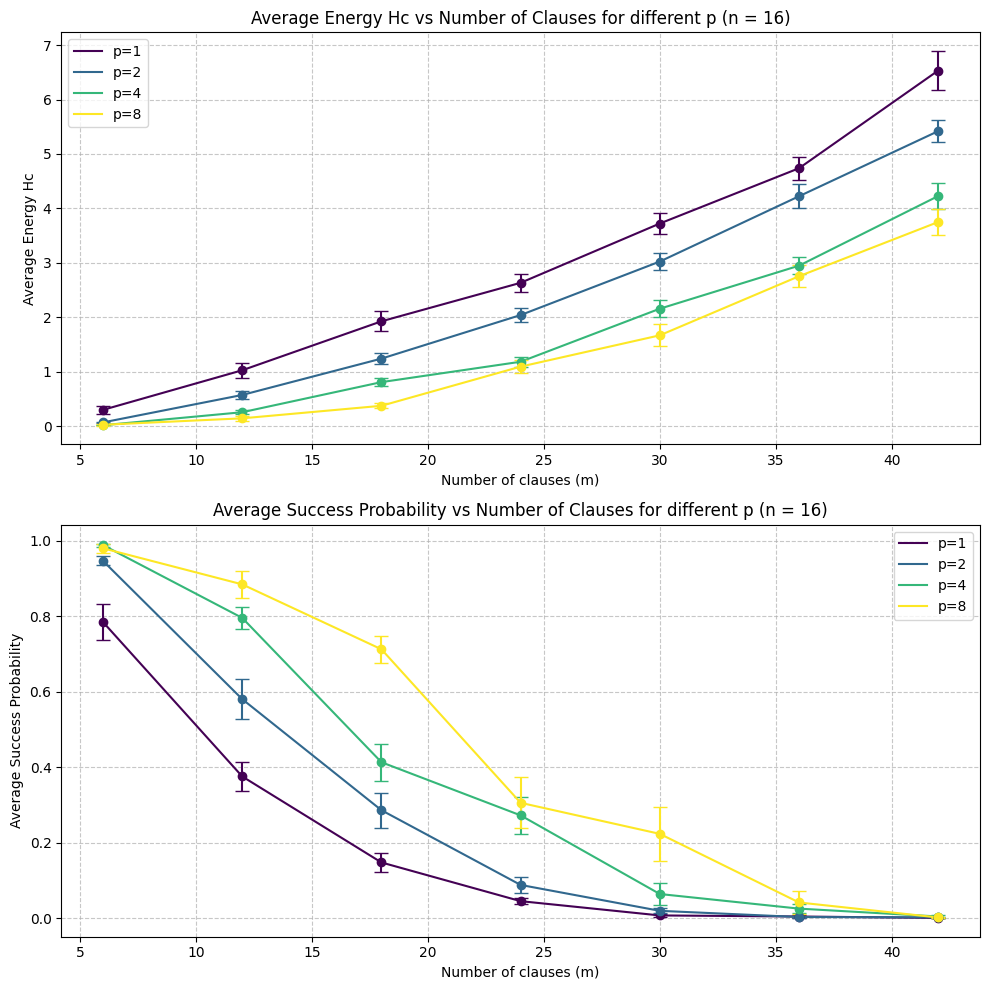

In [47]:
# Plotting the results from summary_df
# Hc energy and success probability vs m for different p values

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
p_list = summary_df['p'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(p_list)))

for idx, p in enumerate(p_list):
    subset = summary_df[summary_df['p'] == p]
    ax[0].plot(subset['m'], subset['energy_Hc_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[0].errorbar(subset['m'], subset['energy_Hc_mean'], yerr=subset['energy_Hc_std'], fmt='o', capsize=5, color=colors[idx])
    ax[1].plot(subset['m'], subset['success_prob_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[1].errorbar(subset['m'], subset['success_prob_mean'], yerr=subset['success_prob_std'], fmt='o', capsize=5, color=colors[idx])

# plot 1 (Energy)
ax[0].set_xlabel('Number of clauses (m)')
ax[0].set_ylabel('Average Energy Hc')
ax[0].set_title(f'Average Energy Hc vs Number of Clauses for different p (n = {n})')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# plot 2 (Success Probability)
ax[1].set_xlabel('Number of clauses (m)')
ax[1].set_ylabel('Average Success Probability')
ax[1].set_title(f'Average Success Probability vs Number of Clauses for different p (n = {n})')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()